In [16]:
import networkx as nx
import pandas as pd
import itertools

In [17]:
df = pd.read_csv("nodes.csv")
df2 = pd.read_csv("filtered_nodes.csv")

G = nx.Graph()

# get set of nodes that should be red
red_nodes = set(df2["name"])

for _, row in df.iterrows():
    node_name = row["name"]
    
    color = "red" if node_name in red_nodes else "blue"
    
    G.add_node(
        node_name,
        station=row["station"],
        lat=row["lat"],
        lng=row["lng"],
        color=color
    )

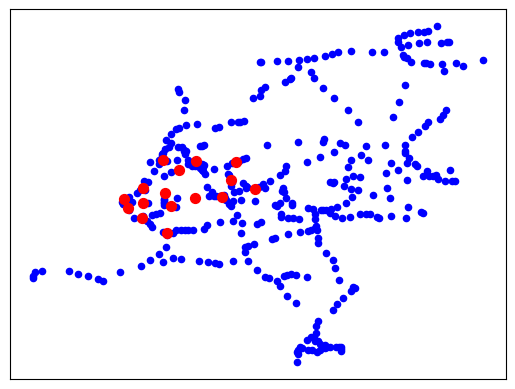

In [18]:
pos = {
    node: (data["lng"], data["lat"])
    for node, data in G.nodes(data=True)
}

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
blue_nodes = [n for n in G.nodes() if G.nodes[n]["color"] != "red"]

# draw blue first
nx.draw_networkx_nodes(
    G, pos,
    nodelist=blue_nodes,
    node_color="blue",
    node_size=20
)

# draw red on top
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50
)

In [19]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [20]:
edges_df = pd.read_csv("edges.csv")

for _, row in edges_df.iterrows():
    n1 = row["from"]
    n2 = row["to"]

    lat1, lon1 = G.nodes[n1]["lat"], G.nodes[n1]["lng"]
    lat2, lon2 = G.nodes[n2]["lat"], G.nodes[n2]["lng"]

    dist = haversine(lat1, lon1, lat2, lon2)

    G.add_edge(n1, n2, weight=dist)

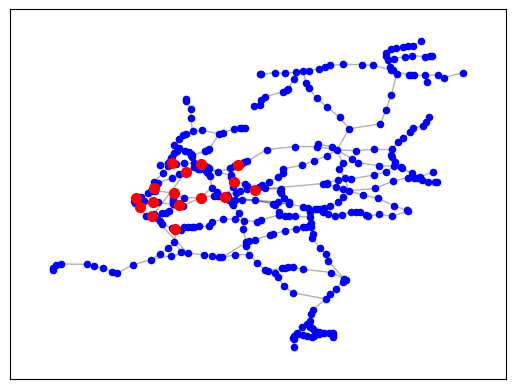

In [21]:
# edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# nodes (layered)
nx.draw_networkx_nodes(G, pos, nodelist=blue_nodes, node_color="blue", node_size=20)
nx.draw_networkx_nodes(G, pos, nodelist=red_nodes, node_color="red", node_size=50)

In [23]:
# all red cities
red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]

results = []

for source, target in itertools.combinations(red_nodes, 2):
    try:
        path = nx.shortest_path(G, source=source, target=target, weight="weight")
        distance = nx.shortest_path_length(G, source=source, target=target, weight="weight")

        results.append({
            "from": source,
            "to": target,
            "distance_km": distance,
            "path": path
        })
    except nx.NetworkXNoPath:
        results.append({
            "from": source,
            "to": target,
            "distance_km": None,
            "path": None
        })

shortest_paths_df = pd.DataFrame(results)

In [24]:
print(shortest_paths_df)

    from   to  distance_km                                               path
0    ALM  APN    43.053440  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, HVSP, ...
1    ALM  AMF    19.382959  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, BRN, AMF]
2    ALM  ASD    21.561287        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
3    ALM   DT    58.697908  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, SH...
4    ALM  GVC    60.727389  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, AS...
..   ...  ...          ...                                                ...
115  SHL   WD    22.189984      [SHL, ASDZ, RAI, DVD, ASB, ASHD, AC, BKL, WD]
116  SHL  ZTM    40.189062  [SHL, HFD, NVP, SSH, LEDN, DVNK, VST, GVM, LAA...
117   UT   WD    14.794005                           [UT, UTZL, MAS, BKL, WD]
118   UT  ZTM    43.276381  [UT, UTZL, MAS, BKL, WD, GDG, GD, LLZM, ZTMO, ...
119   WD  ZTM    28.482377                     [WD, GDG, GD, LLZM, ZTMO, ZTM]

[120 rows x 4 columns]


In [25]:
red_set = set(red_nodes)

direct_connections = []

for _, row in shortest_paths_df.iterrows():
    path = row["path"]
    
    if path is None:
        continue

    # only check intermediate nodes, not start/end
    intermediate_nodes = path[1:-1]

    # keep only if all intermediate nodes are blue
    if all(node not in red_set for node in intermediate_nodes):
        direct_connections.append({
            "from": row["from"],
            "to": row["to"],
            "distance_km": row["distance_km"],
            "path": path
        })

red_city_connections_df = pd.DataFrame(direct_connections)



In [26]:
print(red_city_connections_df)

    from    to  distance_km                                               path
0    ALM   ASD    21.561287        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
1    ALM   HVS     6.527708            [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS]
2    APN    GD     4.887712              [APN, BSK, BSKS, WADN, WAD, WADT, GD]
3    APN  LEDN    12.020389                                   [APN, LDL, LEDN]
4    APN    WD    16.112657                                     [APN, BDG, WD]
5    AMF   HVS    12.855251                                    [AMF, BRN, HVS]
6    AMF    UT    17.765756                           [AMF, DLD, BHV, UTO, UT]
7    ASD   HLM    17.777563                        [ASD, ASS, HWZB, HLMS, HLM]
8    ASD   HVS    19.150371   [ASD, ASDM, ASSP, DMN, WP, NDB, BSMZ, HVSM, HVS]
9    ASD   SHL     9.398063                                         [ASD, SHL]
10   ASD    UT    16.148262  [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, MAS,...
11   ASD    WD    14.599860      [ASD, ASDM, ASA, DV